# 09 - Season Report

This notebook creates a compact, repeatable season report from the saved model outputs and evaluation tables.
It is designed to be rerun after the upstream notebooks and to refresh the project summary without retraining any models.

## 1. Imports and Setup

The report reads saved CSV outputs and deployment metadata.
This keeps the notebook fast and ensures that the displayed numbers are consistent with the latest completed modeling and market-evaluation runs.

In [10]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve().parents[0]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.config import FIGURES_DIR, PROCESSED_DATA_DIR, TABLES_DIR
from src.deployment_helpers import discover_deployment_runs

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 200)


## 2. Load Saved Report Inputs

The report is intentionally resilient to partially completed workflows.
If some optional outputs are not available yet, the notebook keeps running and simply skips the corresponding section.

In [11]:
def safe_read_csv(path: Path) -> pd.DataFrame:
    return pd.read_csv(path) if path.exists() else pd.DataFrame()

deployment_registry = discover_deployment_runs()

classification_summary = safe_read_csv(PROCESSED_DATA_DIR / 'market_evaluation' / 'classification_summary.csv')
probability_summary = safe_read_csv(PROCESSED_DATA_DIR / 'market_evaluation' / 'probability_summary.csv')
betting_summary = safe_read_csv(PROCESSED_DATA_DIR / 'market_evaluation' / 'betting_summary.csv')
binary_focus_registry = safe_read_csv(PROCESSED_DATA_DIR / 'market_evaluation' / 'binary_focus_registry.csv')
binary_focus_classification = safe_read_csv(PROCESSED_DATA_DIR / 'market_evaluation' / 'binary_focus_classification.csv')
binary_focus_probability = safe_read_csv(PROCESSED_DATA_DIR / 'market_evaluation' / 'binary_focus_probability.csv')
binary_focus_betting = safe_read_csv(PROCESSED_DATA_DIR / 'market_evaluation' / 'binary_focus_betting.csv')
matchday_accuracy = safe_read_csv(PROCESSED_DATA_DIR / 'market_evaluation' / 'matchday_accuracy.csv')

ml_betting_model_results = safe_read_csv(PROCESSED_DATA_DIR / 'model_runs' / 'ml_betting_binary' / 'model_results.csv')
ml_betting_strategy_test = safe_read_csv(PROCESSED_DATA_DIR / 'model_runs' / 'ml_betting_binary' / 'strategy_test_results.csv')
ml_betting_best_summary = safe_read_csv(PROCESSED_DATA_DIR / 'model_runs' / 'ml_betting_binary' / 'best_model_summary.csv')
ml_betting_coefficients = safe_read_csv(PROCESSED_DATA_DIR / 'model_runs' / 'ml_betting_binary' / 'best_model_coefficients.csv')

print('Deployment runs found:', len(deployment_registry))
display(deployment_registry)


Deployment runs found: 5


,run_key,display_name,artifact_path,metadata_path,best_model_name,best_feature_set,target_col,primary_metric,trained_through_date,trained_through_matchday,trained_through_season_id
0,double_poisson_binary,Double Poisson binary,C:\Users\cerve\Desktop\DP\match_prediction\out...,C:\Users\cerve\Desktop\DP\match_prediction\out...,double_poisson_alpha_0_1,None,None,None,2026-04-19T17:30:00,34,NaN
1,double_poisson_multiclass,Double Poisson multiclass,C:\Users\cerve\Desktop\DP\match_prediction\out...,C:\Users\cerve\Desktop\DP\match_prediction\out...,double_poisson_alpha_0_1,None,None,None,2026-04-19T17:30:00,34,NaN
2,ml_betting_binary,ML betting binary,C:\Users\cerve\Desktop\DP\match_prediction\out...,C:\Users\cerve\Desktop\DP\match_prediction\out...,logistic_regression,market_only,home_win,log_loss,2026-04-19T17:30:00,30,2025.0
3,ml_binary,ML binary,C:\Users\cerve\Desktop\DP\match_prediction\out...,C:\Users\cerve\Desktop\DP\match_prediction\out...,naive_bayes,top_20_rf,None,None,2026-04-19T17:30:00,34,NaN
4,ml_multiclass,ML multiclass,C:\Users\cerve\Desktop\DP\match_prediction\out...,C:\Users\cerve\Desktop\DP\match_prediction\out...,knn,compact_domain,None,None,2026-04-19T17:30:00,34,NaN


## 3. Current Cutoff Snapshot

The deployment registry shows which saved models are currently available and up to which Bundesliga matchday they were trained.
This is the quickest project-level snapshot when the season is still in progress.

In [12]:
cutoff_snapshot = deployment_registry[
    [
        'display_name',
        'best_model_name',
        'best_feature_set',
        'primary_metric',
        'trained_through_season_id',
        'trained_through_matchday',
        'trained_through_date',
    ]
].sort_values('display_name') if not deployment_registry.empty else pd.DataFrame()

display(cutoff_snapshot)


,display_name,best_model_name,best_feature_set,primary_metric,trained_through_season_id,trained_through_matchday,trained_through_date
0,Double Poisson binary,double_poisson_alpha_0_1,None,None,NaN,34,2026-04-19T17:30:00
1,Double Poisson multiclass,double_poisson_alpha_0_1,None,None,NaN,34,2026-04-19T17:30:00
2,ML betting binary,logistic_regression,market_only,log_loss,2025.0,30,2026-04-19T17:30:00
3,ML binary,naive_bayes,top_20_rf,None,NaN,34,2026-04-19T17:30:00
4,ML multiclass,knn,compact_domain,None,NaN,34,2026-04-19T17:30:00


## 4. Overall Classification Ranking

The first report layer focuses on pure predictive performance against the market benchmark.
These tables answer which saved models currently perform best as classifiers on the matched evaluation sample.

,run_key,display_name,task_group,n_matches,model_accuracy,market_accuracy,accuracy_delta_model_minus_market,model_macro_f1,market_macro_f1,model_weighted_f1,market_weighted_f1
2,ml_binary,ML binary,binary,270,0.700000,0.720833,-0.020833,0.688900,0.701553,0.695865,0.710403
0,double_poisson_binary,Double Poisson binary,binary,270,0.696296,0.720833,-0.024537,0.656403,0.701553,0.670279,0.710403
1,ml_betting_binary,ML betting binary,binary,270,0.688889,0.720833,-0.031944,0.658947,0.701553,0.670924,0.710403
3,double_poisson_multiclass,Double Poisson multiclass,multiclass,270,0.555556,0.558333,-0.002778,0.403330,0.410961,0.467522,0.473259
4,ml_multiclass,ML multiclass,multiclass,270,0.514815,0.558333,-0.043519,0.457888,0.410961,0.493053,0.473259


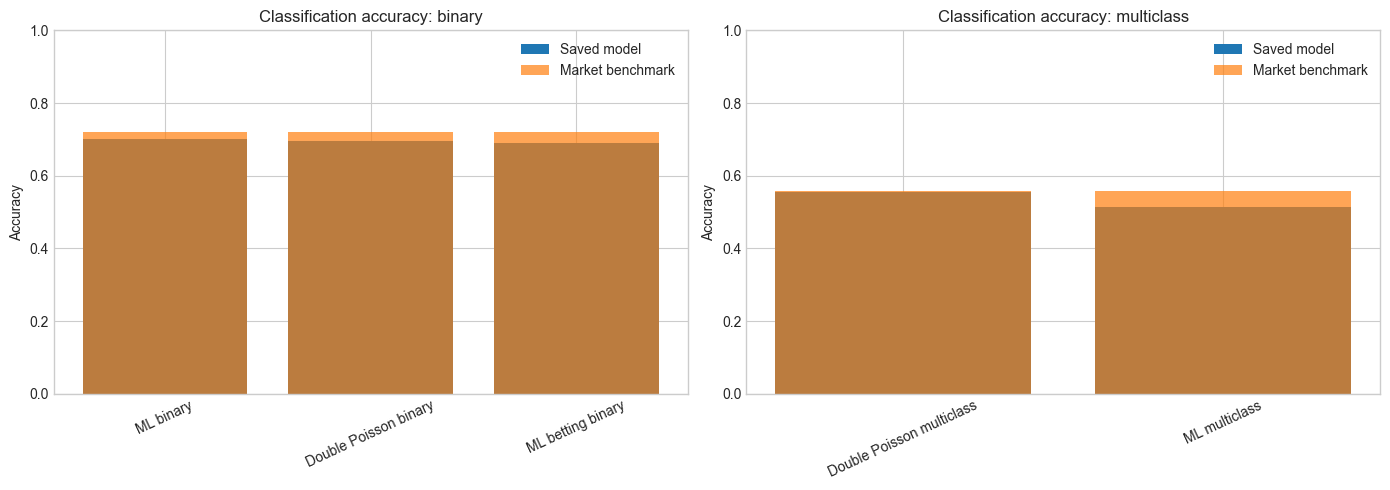

In [13]:
if classification_summary.empty:
    print('Classification summary is not available yet. Run notebook 08 first.')
else:
    display(classification_summary.sort_values(['task_group', 'model_accuracy'], ascending=[True, False]))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), squeeze=False)
    for ax, task_group in zip(axes[0], ['binary', 'multiclass']):
        subset = classification_summary.loc[classification_summary['task_group'] == task_group].copy()
        if subset.empty:
            ax.axis('off')
            continue
        subset = subset.sort_values('model_accuracy', ascending=False)
        ax.bar(subset['display_name'], subset['model_accuracy'], label='Saved model')
        ax.bar(subset['display_name'], subset['market_accuracy'], alpha=0.7, label='Market benchmark')
        ax.set_title(f'Classification accuracy: {task_group}')
        ax.set_ylabel('Accuracy')
        ax.set_ylim(0, 1)
        ax.tick_params(axis='x', rotation=25)
        ax.legend()
    plt.tight_layout()
    report_classification_fig = fig
    plt.show()


## 5. Matchday Dynamics

Aggregate season-level metrics can hide instability.
This section follows performance through the season so that the report also reflects whether the models keep their level from round to round.

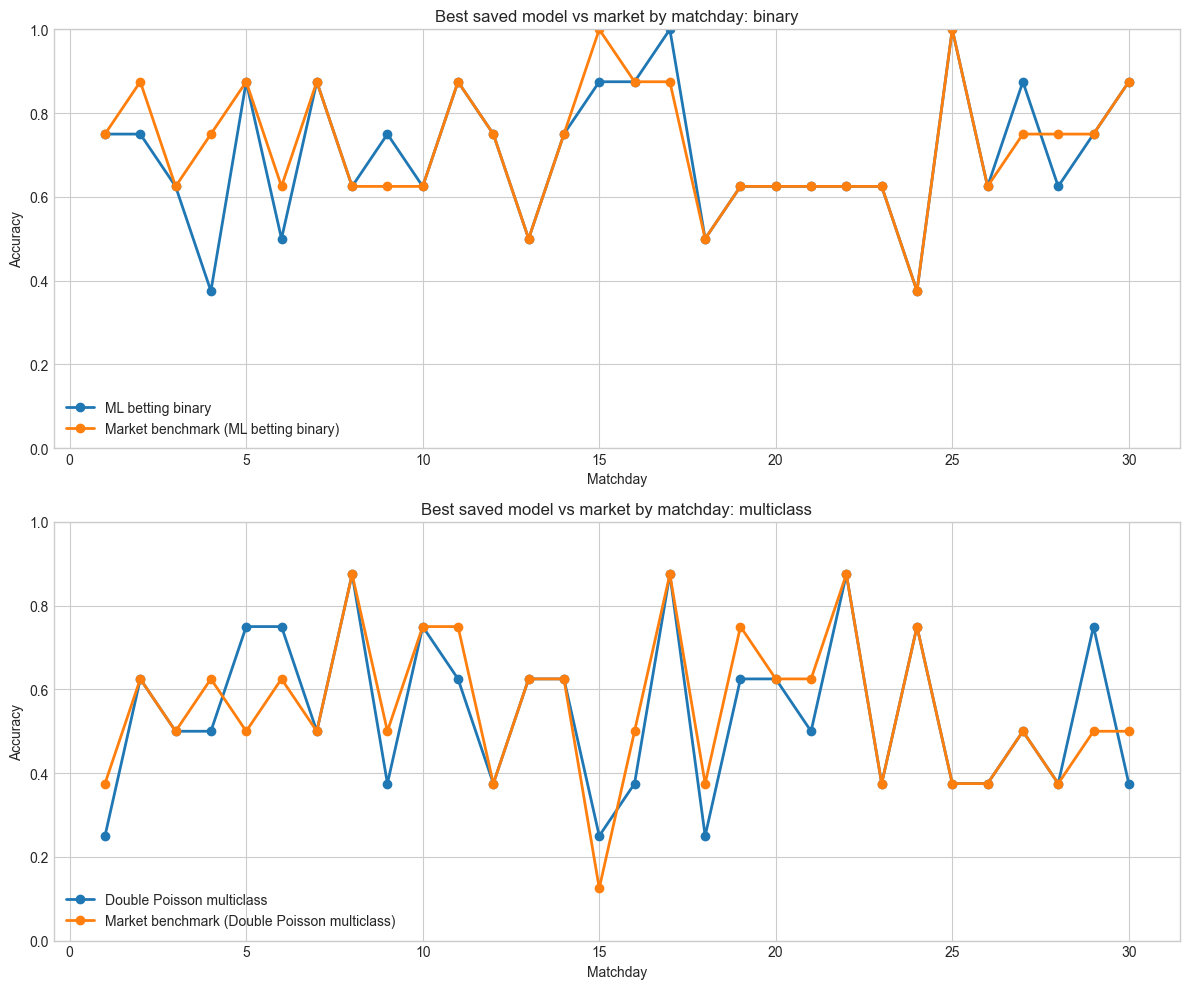

In [14]:
if matchday_accuracy.empty:
    print('Matchday accuracy table is not available yet.')
else:
    matchday_accuracy['matchday'] = pd.to_numeric(matchday_accuracy['matchday'], errors='coerce')
    top_competitors = []
    for task_group in matchday_accuracy['task_group'].dropna().unique():
        subset = matchday_accuracy.loc[matchday_accuracy['task_group'] == task_group].copy()
        model_subset = subset.loc[~subset['competitor'].str.startswith('Market benchmark')].copy()
        if not model_subset.empty:
            top_competitor = (
                model_subset.groupby('competitor', as_index=False)['accuracy']
                .mean()
                .sort_values('accuracy', ascending=False)
                .iloc[0]['competitor']
            )
            top_competitors.extend([top_competitor, f'Market benchmark ({top_competitor})'])

    focus_df = matchday_accuracy.loc[matchday_accuracy['competitor'].isin(top_competitors)].copy()
    if focus_df.empty:
        print('No focused matchday trajectories are available.')
    else:
        fig, axes = plt.subplots(len(focus_df['task_group'].dropna().unique()), 1, figsize=(12, 5 * max(len(focus_df['task_group'].dropna().unique()), 1)), squeeze=False)
        for ax, task_group in zip(axes[:, 0], focus_df['task_group'].dropna().unique()):
            subset = focus_df.loc[focus_df['task_group'] == task_group].copy()
            for competitor, group in subset.groupby('competitor'):
                group = group.sort_values('matchday')
                ax.plot(group['matchday'], group['accuracy'], marker='o', linewidth=2, label=competitor)
            ax.set_title(f'Best saved model vs market by matchday: {task_group}')
            ax.set_xlabel('Matchday')
            ax.set_ylabel('Accuracy')
            ax.set_ylim(0, 1)
            ax.legend(loc='best')
        plt.tight_layout()
        report_matchday_fig = fig
        plt.show()


## 6. Focused Binary Comparison: 05b vs 05c

This is the most important comparison for the betting-oriented branch of the project.
It isolates the difference between the standard binary ML workflow and the market-aware binary betting workflow.

In [15]:
if binary_focus_classification.empty:
    print('Binary focus tables are not available yet. Run notebook 08 after 05b and 05c finish.')
else:
    display(binary_focus_registry.sort_values('display_name') if not binary_focus_registry.empty else pd.DataFrame())
    display(binary_focus_classification.sort_values('display_name'))

    if not binary_focus_probability.empty:
        display(binary_focus_probability.sort_values(['display_name', 'probability_view', 'competitor']))

    if not binary_focus_betting.empty:
        display(binary_focus_betting.sort_values(['display_name', 'strategy_type', 'bet_view', 'edge_threshold']))


""


,run_key,display_name,task_group,n_matches,model_accuracy,market_accuracy,accuracy_delta_model_minus_market,model_macro_f1,market_macro_f1,model_weighted_f1,market_weighted_f1
0,ml_betting_binary,ML betting binary,binary,270,0.688889,0.720833,-0.031944,0.658947,0.701553,0.670924,0.710403
1,ml_binary,ML binary,binary,270,0.700000,0.720833,-0.020833,0.688900,0.701553,0.695865,0.710403


,run_key,display_name,task_group,probability_view,competitor,n_matches,log_loss,brier_score,multiclass_brier
2,ml_betting_binary,ML betting binary,binary,Away not lose,ML betting binary,270,0.601707,0.206982,NaN
3,ml_betting_binary,ML betting binary,binary,Away not lose,Market benchmark,240,0.587641,0.201016,NaN
0,ml_betting_binary,ML betting binary,binary,Home win,ML betting binary,270,0.601707,0.206982,NaN
1,ml_betting_binary,ML betting binary,binary,Home win,Market benchmark,240,0.587641,0.201016,NaN


,run_key,display_name,bet_view,strategy_type,edge_threshold,n_bets,hit_rate,roi,avg_edge,avg_offered_odds,total_profit
3,ml_betting_binary,ML betting binary,Bet every away not lose,blanket_all,0.000,240,0.558333,-0.025701,0.000000,2.059695,-6.168193
2,ml_betting_binary,ML betting binary,Bet every home win,blanket_all,0.000,240,0.441667,-0.132625,0.000000,2.592667,-31.830000
5,ml_betting_binary,ML betting binary,Away not lose value bets,value_edge,0.025,117,0.683761,0.038067,0.069455,1.650855,4.453816
7,ml_betting_binary,ML betting binary,Away not lose value bets,value_edge,0.050,68,0.588235,-0.015577,0.092816,1.794793,-1.059230
9,ml_betting_binary,ML betting binary,Away not lose value bets,value_edge,0.075,41,0.585366,0.001132,0.114731,1.791556,0.046417
4,ml_betting_binary,ML betting binary,Home win value bets,value_edge,0.025,43,0.697674,0.056977,0.046146,1.520233,2.450000
6,ml_betting_binary,ML betting binary,Home win value bets,value_edge,0.050,16,0.562500,-0.201875,0.063905,1.433125,-3.230000
8,ml_betting_binary,ML betting binary,Home win value bets,value_edge,0.075,2,0.500000,-0.335000,0.078207,1.370000,-0.670000
1,ml_binary,ML binary,Bet every away not lose,blanket_all,0.000,240,0.558333,-0.025701,0.000000,2.059695,-6.168193
0,ml_binary,ML binary,Bet every home win,blanket_all,0.000,240,0.441667,-0.132625,0.000000,2.592667,-31.830000


## 7. Betting Snapshot

The ROI tables below should be interpreted as descriptive portfolio summaries, not as proof of persistent profitability.
Their role in the report is to show which saved strategies currently look most promising and how they compare with blanket benchmarks.

,run_key,display_name,bet_view,strategy_type,edge_threshold,n_bets,hit_rate,roi,avg_edge,avg_offered_odds,total_profit
0,ml_binary,ML binary,Bet every away not lose,blanket_all,0.000,240,0.558333,-0.025701,0.000000,2.059695,-6.168193
1,ml_betting_binary,ML betting binary,Bet every away not lose,blanket_all,0.000,240,0.558333,-0.025701,0.000000,2.059695,-6.168193
2,double_poisson_binary,Double Poisson binary,Bet every away not lose,blanket_all,0.000,240,0.558333,-0.025701,0.000000,2.059695,-6.168193
3,ml_binary,ML binary,Bet every home win,blanket_all,0.000,240,0.441667,-0.132625,0.000000,2.592667,-31.830000
4,ml_betting_binary,ML betting binary,Bet every home win,blanket_all,0.000,240,0.441667,-0.132625,0.000000,2.592667,-31.830000
5,double_poisson_binary,Double Poisson binary,Bet every home win,blanket_all,0.000,240,0.441667,-0.132625,0.000000,2.592667,-31.830000
6,ml_betting_binary,ML betting binary,Home win value bets,value_edge,0.025,43,0.697674,0.056977,0.046146,1.520233,2.450000
7,ml_betting_binary,ML betting binary,Away not lose value bets,value_edge,0.025,117,0.683761,0.038067,0.069455,1.650855,4.453816
8,ml_betting_binary,ML betting binary,Away not lose value bets,value_edge,0.075,41,0.585366,0.001132,0.114731,1.791556,0.046417
9,ml_betting_binary,ML betting binary,Away not lose value bets,value_edge,0.050,68,0.588235,-0.015577,0.092816,1.794793,-1.059230


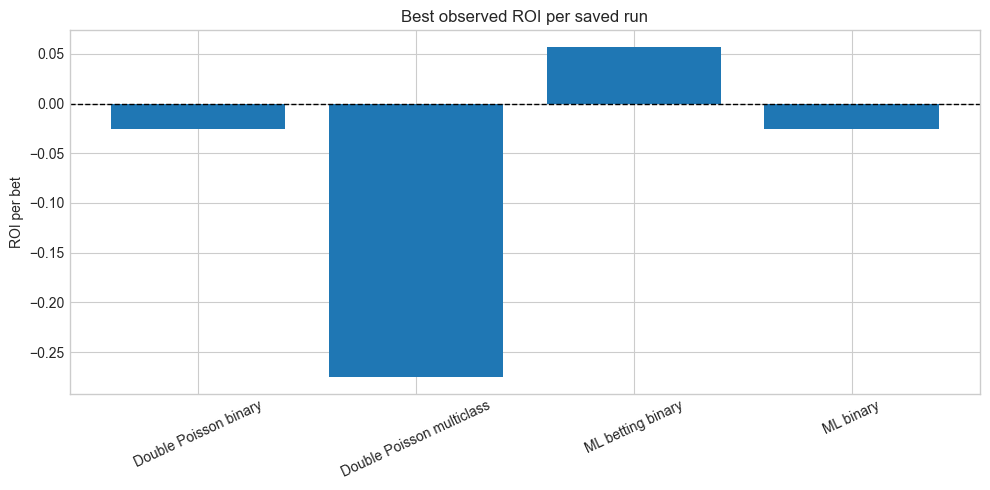

In [16]:
if betting_summary.empty:
    print('Betting summary is not available yet.')
else:
    betting_report = betting_summary.sort_values(['strategy_type', 'roi'], ascending=[True, False]).reset_index(drop=True)
    display(betting_report)

    roi_plot_df = betting_summary.dropna(subset=['roi']).copy()
    if not roi_plot_df.empty:
        top_rows = (
            roi_plot_df.sort_values('roi', ascending=False)
            .groupby('display_name', as_index=False)
            .first()[['display_name', 'bet_view', 'roi']]
        )
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.bar(top_rows['display_name'], top_rows['roi'])
        ax.axhline(0, color='black', linestyle='--', linewidth=1)
        ax.set_title('Best observed ROI per saved run')
        ax.set_ylabel('ROI per bet')
        ax.tick_params(axis='x', rotation=25)
        plt.tight_layout()
        report_betting_fig = fig
        plt.show()


## 8. Market-Aware Betting Model Details

If notebook `05c` has already been rerun after the latest changes, this section shows the best market-aware model, its out-of-sample strategy results, and the logistic-regression coefficient table when applicable.

In [17]:
if ml_betting_model_results.empty:
    print('No saved market-aware betting results were found yet.')
else:
    display(ml_betting_model_results.sort_values(['evaluation_split', 'log_loss', 'brier_score']))

    if not ml_betting_strategy_test.empty:
        display(ml_betting_strategy_test.sort_values('roi', ascending=False))

    if not ml_betting_best_summary.empty:
        display(ml_betting_best_summary)

    if not ml_betting_coefficients.empty:
        display(ml_betting_coefficients)


,model,accuracy,macro_f1,weighted_f1,log_loss,brier_score,multiclass_brier,evaluation_split,feature_set
0,logistic_regression,0.683007,0.649195,0.674109,0.665949,0.229138,NaN,development,market_only
1,hist_gradient_boosting,0.640523,0.587176,0.621124,0.689457,0.233492,NaN,development,market_only
2,naive_bayes,0.673203,0.647920,0.669503,1.584698,0.285004,NaN,development,market_only
3,logistic_regression,0.688889,0.658947,0.670924,0.603707,0.203453,NaN,test,market_only
4,hist_gradient_boosting,0.651852,0.635009,0.644302,0.684603,0.238284,NaN,test,market_only
5,naive_bayes,0.692593,0.673680,0.682991,1.336703,0.254041,NaN,test,market_only


,strategy_name,threshold,n_bets,hit_rate,roi,total_profit,avg_edge,avg_odds,model,feature_set,evaluation_split
3,home_win_value,0.02,50,0.700000,0.092600,4.630000,0.042895,1.564200,logistic_regression,market_only,test
1,home_win_value,0.10,53,0.603774,0.066792,3.540000,0.181671,1.847547,hist_gradient_boosting,market_only,test
4,away_not_lose_value,0.10,82,0.731707,0.043482,3.565508,0.167188,1.472183,naive_bayes,market_only,test
0,away_not_lose_value,0.08,77,0.636364,0.034986,2.693922,0.160428,1.714618,hist_gradient_boosting,market_only,test
5,home_win_value,0.10,60,0.700000,0.032667,1.960000,0.185911,1.500167,naive_bayes,market_only,test
2,away_not_lose_value,0.04,88,0.636364,0.007043,0.619809,0.081725,1.716074,logistic_regression,market_only,test


## 9. Save the Report Outputs

The report tables and figures are saved so that the current state of the project can be reused in thesis writing or compared with a later rerun.

In [18]:
report_processed_dir = PROCESSED_DATA_DIR / 'season_report'
report_tables_dir = TABLES_DIR / 'season_report'
report_figures_dir = FIGURES_DIR / 'season_report'

report_processed_dir.mkdir(parents=True, exist_ok=True)
report_tables_dir.mkdir(parents=True, exist_ok=True)
report_figures_dir.mkdir(parents=True, exist_ok=True)

if not cutoff_snapshot.empty:
    cutoff_snapshot.to_csv(report_processed_dir / 'cutoff_snapshot.csv', index=False)
    cutoff_snapshot.to_csv(report_tables_dir / 'cutoff_snapshot.csv', index=False)
if not classification_summary.empty:
    classification_summary.to_csv(report_processed_dir / 'classification_summary.csv', index=False)
if not binary_focus_classification.empty:
    binary_focus_classification.to_csv(report_processed_dir / 'binary_focus_classification.csv', index=False)
if not betting_summary.empty:
    betting_summary.to_csv(report_processed_dir / 'betting_summary.csv', index=False)
if not ml_betting_strategy_test.empty:
    ml_betting_strategy_test.to_csv(report_processed_dir / 'ml_betting_strategy_test.csv', index=False)
if not ml_betting_coefficients.empty:
    ml_betting_coefficients.to_csv(report_processed_dir / 'ml_betting_coefficients.csv', index=False)

if 'report_classification_fig' in globals():
    report_classification_fig.savefig(report_figures_dir / 'classification_overview.png', dpi=150, bbox_inches='tight')
if 'report_matchday_fig' in globals():
    report_matchday_fig.savefig(report_figures_dir / 'matchday_focus.png', dpi=150, bbox_inches='tight')
if 'report_betting_fig' in globals():
    report_betting_fig.savefig(report_figures_dir / 'betting_snapshot.png', dpi=150, bbox_inches='tight')

print('Saved report tables to:', report_tables_dir)
print('Saved report figures to:', report_figures_dir)
print('Saved report processed outputs to:', report_processed_dir)


Saved report tables to: C:\Users\cerve\Desktop\DP\match_prediction\outputs\tables\season_report
Saved report figures to: C:\Users\cerve\Desktop\DP\match_prediction\outputs\figures\season_report
Saved report processed outputs to: C:\Users\cerve\Desktop\DP\match_prediction\data\processed\season_report
